# Analyse exploratoire des données — EDA

L’objectif de ce notebook est d’étudier les caractéristiques des assurés, la fréquence des sinistres, leur coût et les relations entre les variables explicatives et le niveau de risque.

Cette analyse permettra de préparer :

- la modélisation prédictive du risque ;
- la sélection des variables ;
- la construction des groupes d’assurance collaborative.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [33]:
sns.set_theme(
    style="whitegrid",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (8, 4)

In [34]:
processed_data_path = Path(
    "../data/processed/cleaned_data.csv"
)

df = pd.read_csv(processed_data_path)

In [35]:
print(f"Dimensions : {df.shape}")

df.head()

Dimensions : (122935, 26)


,gender,Age_client,year,age_of_car_M,Car_power_M,Car_2ndDriver_M,num_policiesC,metro_code,Policy_PaymentMethodA,Policy_PaymentMethodH,...,NClaims2,Claims1,Claims2,Types,PolID,Total_NClaims,Total_Claims,Has_Claim,Has_Paid_Claim,Average_Claim_Severity
0,1,84,1,13,90.0,0,1,0,0,1,...,0,0.0,0.0,1,1,0,0.0,0,0,NaN
1,1,83,1,0,177.0,0,1,0,1,1,...,0,0.0,0.0,1,2,0,0.0,0,0,NaN
2,1,85,1,0,163.0,0,1,0,1,1,...,0,0.0,0.0,1,3,0,0.0,0,0,NaN
3,1,85,1,0,90.0,0,1,0,1,1,...,0,0.0,0.0,1,4,0,0.0,0,0,NaN
4,1,82,1,20,115.0,0,1,0,1,1,...,0,0.0,0.0,1,5,0,0.0,0,0,NaN


In [36]:
quality_check = pd.Series({
    "Nombre_lignes": df.shape[0],
    "Nombre_colonnes": df.shape[1],
    "Doublons": df.duplicated().sum(),
    "Valeurs_manquantes": df.isnull().sum().sum(),
    "Contrats_uniques": df["PolID"].nunique()
})

quality_check

Nombre_lignes         122935
Nombre_colonnes           26
Doublons                   0
Valeurs_manquantes    116085
Contrats_uniques       40284
dtype: int64

In [37]:
df.isnull().sum()[
    df.isnull().sum() > 0
]

Average_Claim_Severity    116085
dtype: int64

In [38]:
numerical_features = [
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "Client_Seniority"
]

binary_features = [
    "gender",
    "Car_2ndDriver_M",
    "num_policiesC",
    "metro_code",
    "Policy_PaymentMethodA",
    "Policy_PaymentMethodH",
    "appartment"
]

target_features = [
    "Has_Claim",
    "Total_NClaims",
    "Total_Claims",
    "Has_Paid_Claim",
    "Average_Claim_Severity"
]

## 1. Analyse univariée des variables numériques

In [39]:
numerical_summary = df[
    numerical_features
].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Age_client,122935.0,59.665856,12.948591,18.000000,50.000000,59.000000,70.000000,95.000000
age_of_car_M,122935.0,8.849612,6.214193,0.000000,4.000000,9.000000,13.000000,68.000000
Car_power_M,122935.0,111.532338,44.413744,4.000000,82.000000,105.000000,130.000000,560.000000
Insuredcapital_content_re,122935.0,10.328875,0.706365,2.424803,9.976885,10.362401,10.712612,14.445843
Insuredcapital_continent_re,122935.0,11.480258,0.917154,5.736669,11.180437,11.556533,12.007364,15.364570
Client_Seniority,122935.0,10.265215,5.078371,5.002053,6.579055,8.049281,12.859685,44.706366


In [40]:
numerical_summary["median"] = df[
    numerical_features
].median()

numerical_summary

,count,mean,std,min,25%,50%,75%,max,median
Age_client,122935.0,59.665856,12.948591,18.000000,50.000000,59.000000,70.000000,95.000000,59.000000
age_of_car_M,122935.0,8.849612,6.214193,0.000000,4.000000,9.000000,13.000000,68.000000,9.000000
Car_power_M,122935.0,111.532338,44.413744,4.000000,82.000000,105.000000,130.000000,560.000000,105.000000
Insuredcapital_content_re,122935.0,10.328875,0.706365,2.424803,9.976885,10.362401,10.712612,14.445843,10.362401
Insuredcapital_continent_re,122935.0,11.480258,0.917154,5.736669,11.180437,11.556533,12.007364,15.364570,11.556533
Client_Seniority,122935.0,10.265215,5.078371,5.002053,6.579055,8.049281,12.859685,44.706366,8.049281


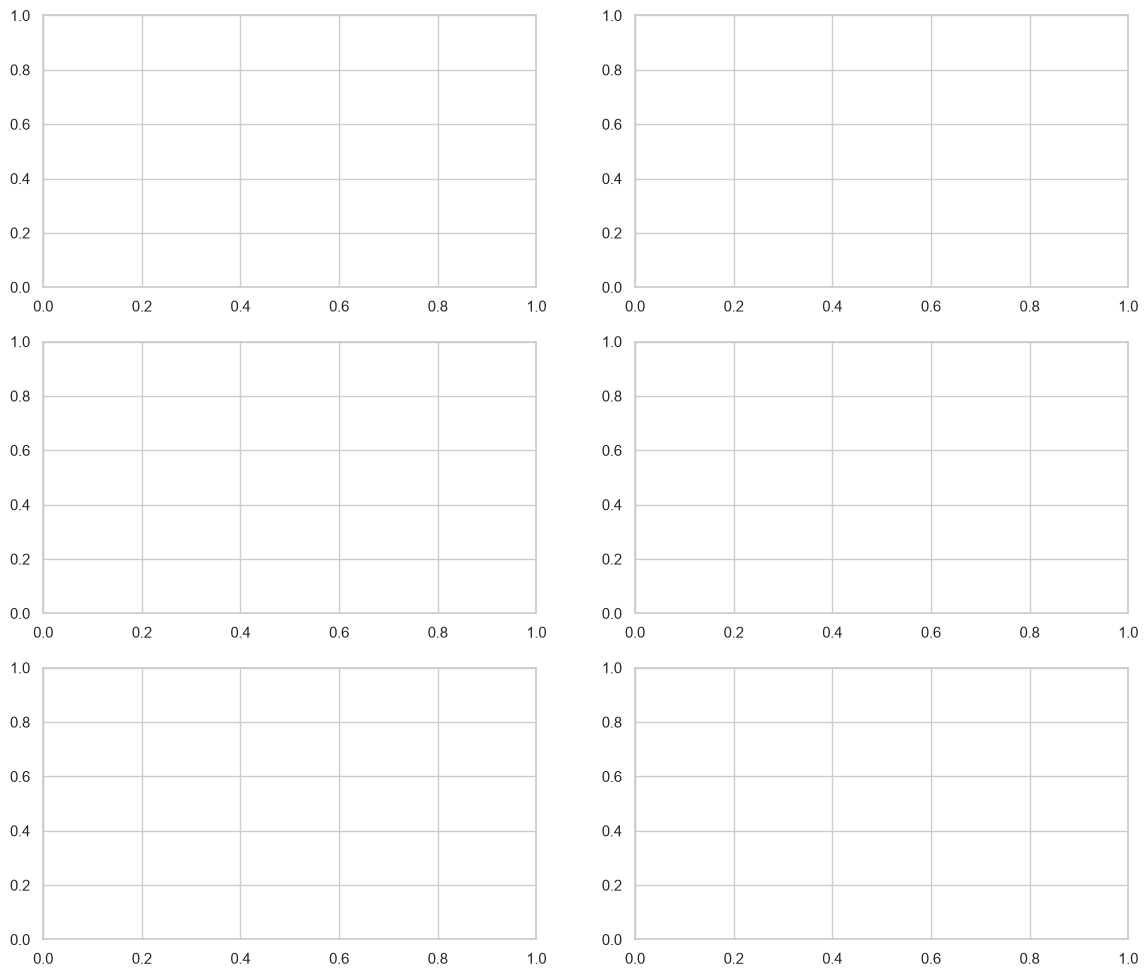

In [41]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 12)
)

axes = axes.flatten()

In [42]:
for index, column in enumerate(numerical_features):
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        ax=axes[index]
    )

    axes[index].set_title(
        f"Distribution de {column}"
    )

plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

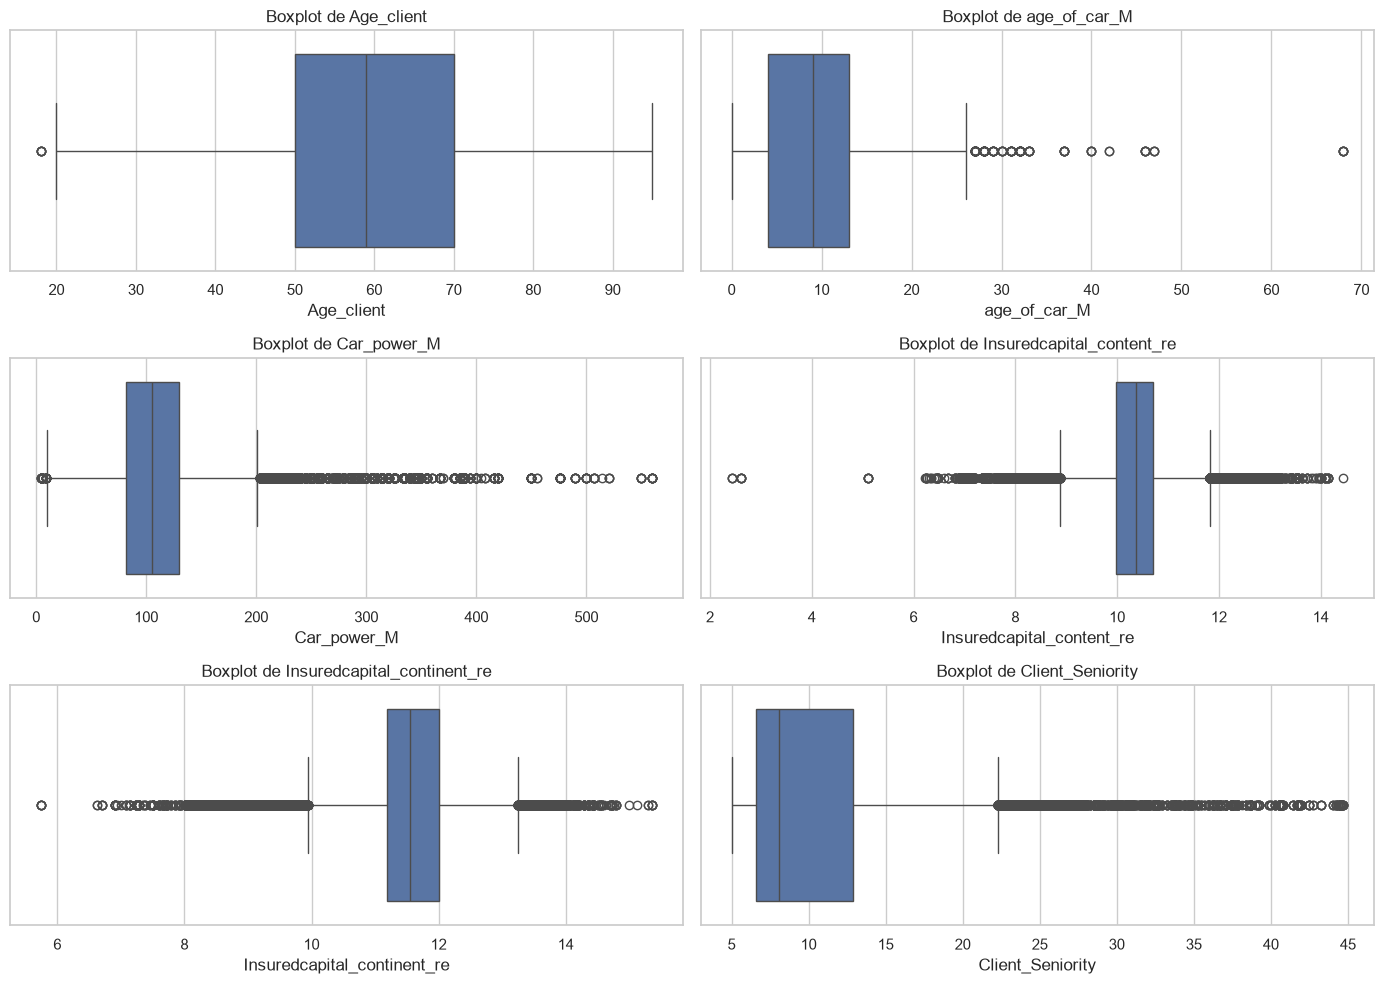

In [43]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(14, 10)
)

axes = axes.flatten()

for index, column in enumerate(numerical_features):
    sns.boxplot(
        data=df,
        x=column,
        ax=axes[index]
    )

    axes[index].set_title(
        f"Boxplot de {column}"
    )

plt.tight_layout()
plt.show()

## 2. Analyse univariée des variables catégorielles binaires

In [44]:
binary_proportions = {}

for column in binary_features:
    binary_proportions[column] = (
        df[column]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

binary_proportions

{'gender': gender
 0    22.18
 1    77.82
 Name: proportion, dtype: float64,
 'Car_2ndDriver_M': Car_2ndDriver_M
 0    86.15
 1    13.85
 Name: proportion, dtype: float64,
 'num_policiesC': num_policiesC
 0    18.94
 1    81.06
 Name: proportion, dtype: float64,
 'metro_code': metro_code
 0    83.64
 1    16.36
 Name: proportion, dtype: float64,
 'Policy_PaymentMethodA': Policy_PaymentMethodA
 0    22.93
 1    77.07
 Name: proportion, dtype: float64,
 'Policy_PaymentMethodH': Policy_PaymentMethodH
 0     7.43
 1    92.57
 Name: proportion, dtype: float64,
 'appartment': appartment
 0    37.06
 1    62.94
 Name: proportion, dtype: float64}

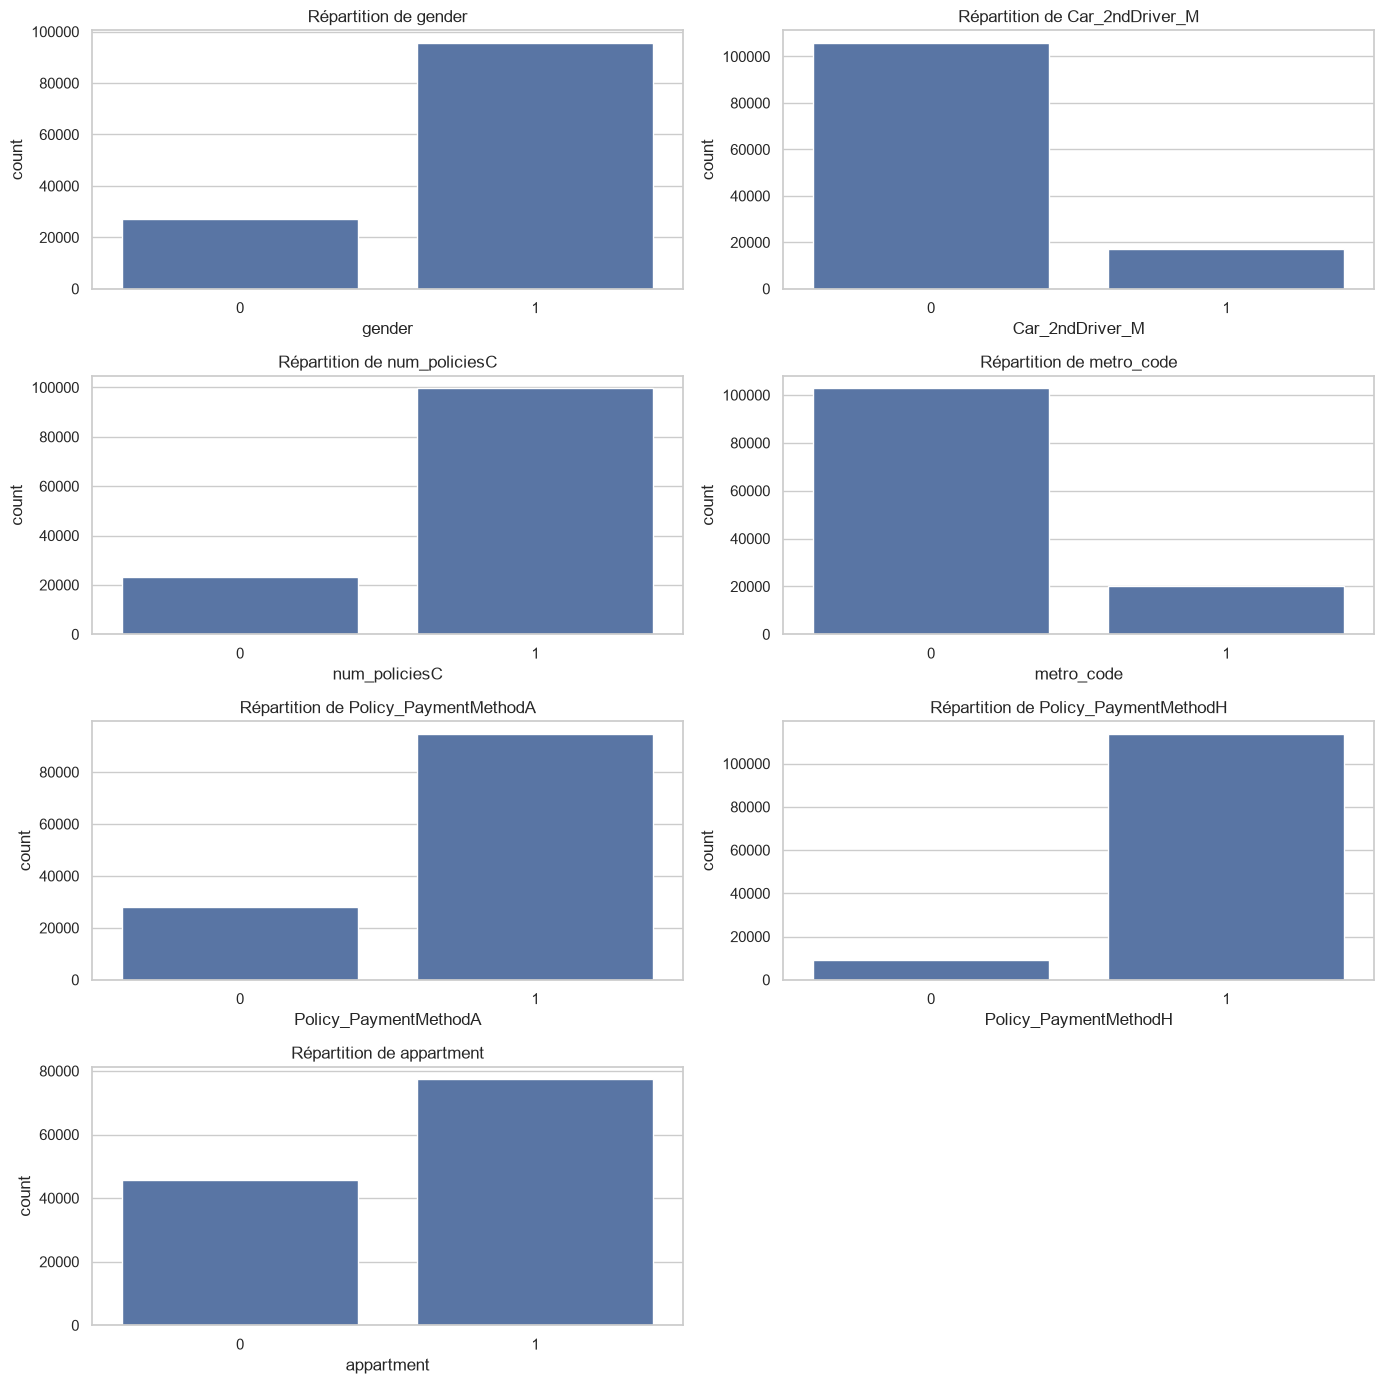

In [45]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 14)
)

axes = axes.flatten()

for index, column in enumerate(binary_features):
    sns.countplot(
        data=df,
        x=column,
        ax=axes[index]
    )

    axes[index].set_title(
        f"Répartition de {column}"
    )

axes[-1].axis("off")

plt.tight_layout()
plt.show()

### Premières observations

- Les variables numériques possèdent des échelles très différentes, ce qui nécessitera une standardisation avant le clustering.
- Certaines variables présentent des distributions asymétriques et des valeurs extrêmes.
- Plusieurs variables binaires sont déséquilibrées, avec une modalité largement majoritaire.
- Ces déséquilibres ne justifient pas une suppression automatique, mais devront être considérés pendant la modélisation et l’interprétation des groupes.

## 3. Analyse bivariée des variables catégorielles

Cette section compare la fréquence et le coût des sinistres entre les différentes modalités des variables catégorielles.

In [46]:
def risk_summary_by_category(data, column):
    summary = data.groupby(column).agg(
        Nombre_observations=("PolID", "size"),
        Nombre_contrats=("PolID", "nunique"),
        Taux_sinistre=("Has_Claim", "mean"),
        Frequence_moyenne=("Total_NClaims", "mean"),
        Cout_moyen=("Total_Claims", "mean"),
        Cout_total=("Total_Claims", "sum")
    )

    summary["Taux_sinistre"] = (
        summary["Taux_sinistre"] * 100
    )

    return summary.round(2)

In [47]:
risk_summary_by_category(
    df,
    "gender"
)

,Nombre_observations,Nombre_contrats,Taux_sinistre,Frequence_moyenne,Cout_moyen,Cout_total
gender,,,,,,
0,27264,8964,5.64,0.06,36.11,984503.43
1,95671,31320,5.55,0.06,33.85,3238029.24


In [48]:
for column in binary_features:
    print(f"\nRésumé du risque pour : {column}")

    display(
        risk_summary_by_category(
            df,
            column
        )
    )


Résumé du risque pour : gender


,Nombre_observations,Nombre_contrats,Taux_sinistre,Frequence_moyenne,Cout_moyen,Cout_total
gender,,,,,,
0,27264,8964,5.64,0.06,36.11,984503.43
1,95671,31320,5.55,0.06,33.85,3238029.24



Résumé du risque pour : Car_2ndDriver_M


,Nombre_observations,Nombre_contrats,Taux_sinistre,Frequence_moyenne,Cout_moyen,Cout_total
Car_2ndDriver_M,,,,,,
0,105909,34270,5.33,0.06,31.80,3368140.75
1,17026,6014,7.06,0.08,50.18,854391.92



Résumé du risque pour : num_policiesC


...

,Nombre_observations,Nombre_contrats,Taux_sinistre,Frequence_moyenne,Cout_moyen,Cout_total
Policy_PaymentMethodA,,,,,,
0,28191,10118,6.89,0.08,43.49,1226102.60
1,94744,30166,5.18,0.06,31.63,2996430.07



Résumé du risque pour : Policy_PaymentMethodH


,Nombre_observations,Nombre_contrats,Taux_sinistre,Frequence_moyenne,Cout_moyen,Cout_total
Policy_PaymentMethodH,,,,,,
0,9133,3157,6.68,0.08,43.40,396377.18
1,113802,37127,5.48,0.06,33.62,3826155.49



Résumé du risque pour : appartment


,Nombre_observations,Nombre_contrats,Taux_sinistre,Frequence_moyenne,Cout_moyen,Cout_total
appartment,,,,,,
0,45557,14763,3.69,0.04,37.21,1695313.00
1,77378,25521,6.68,0.08,32.66,2527219.67


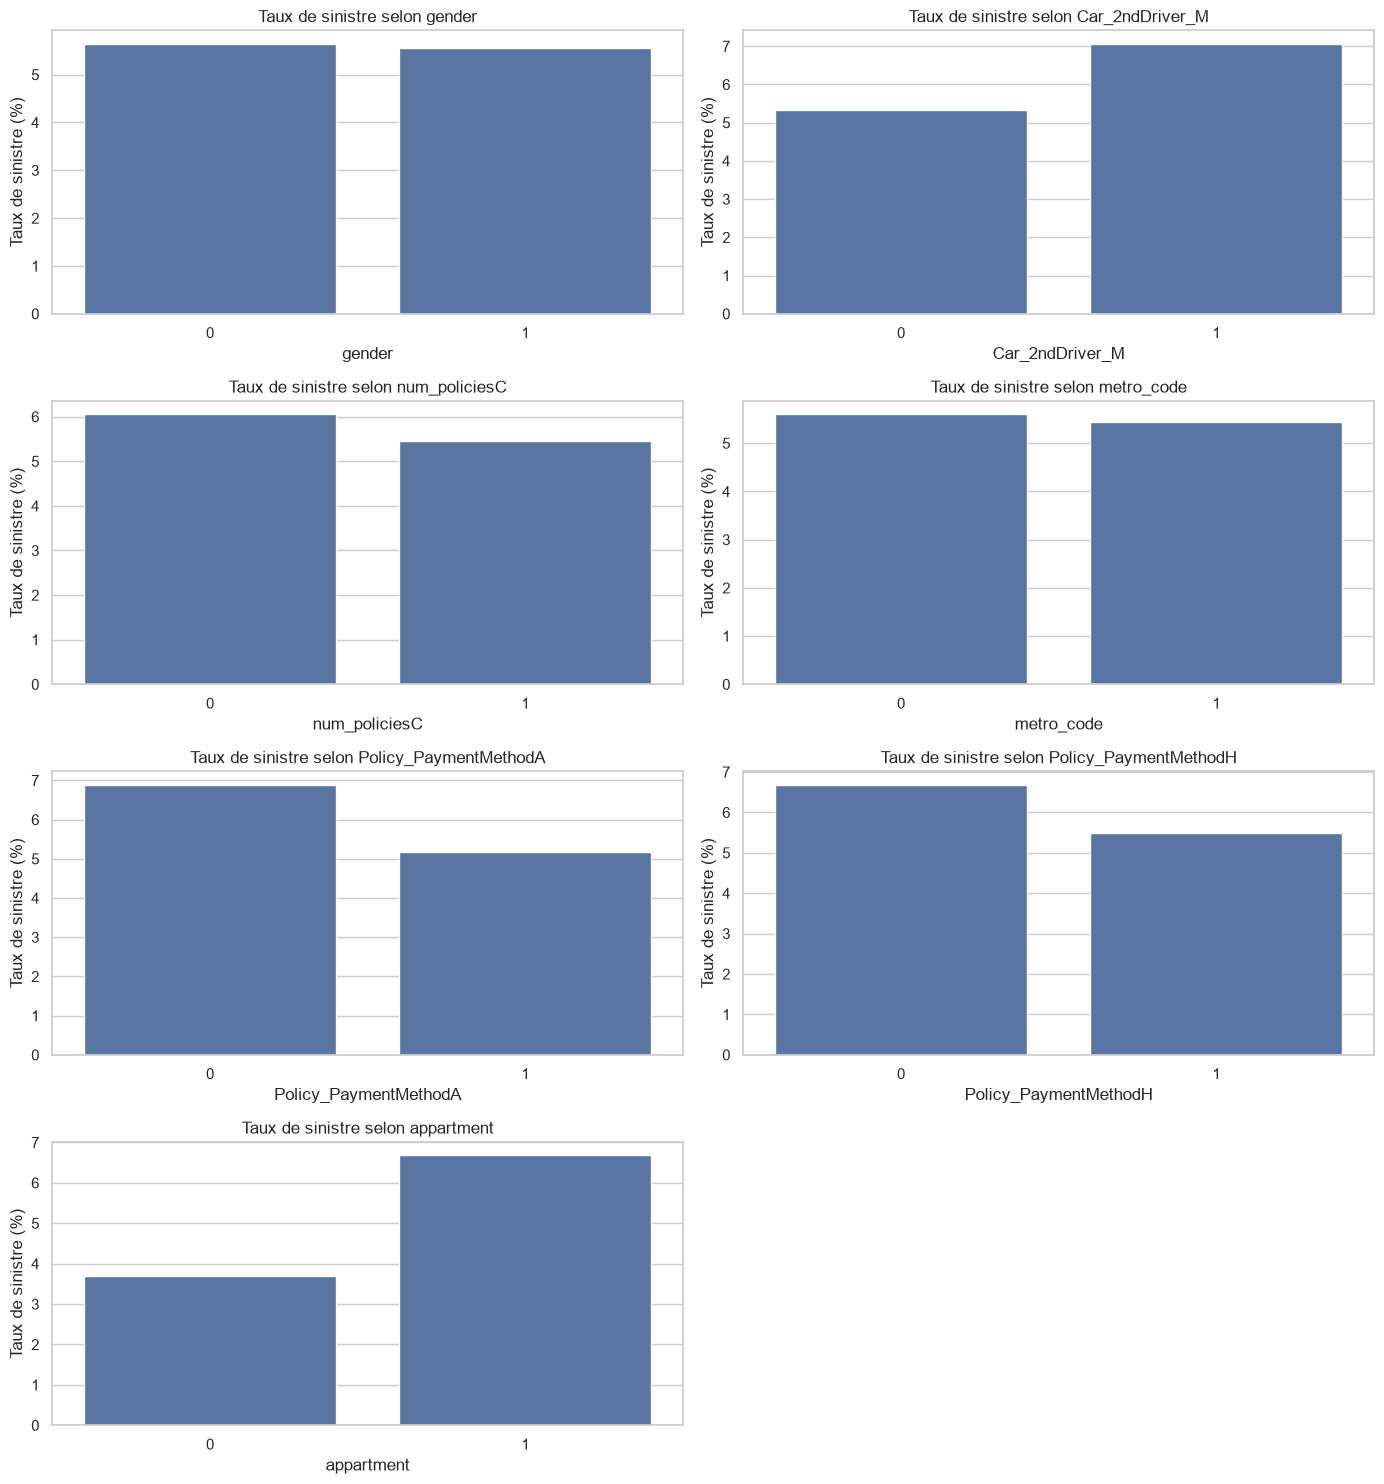

In [49]:
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(14, 15)
)

axes = axes.flatten()

for index, column in enumerate(binary_features):
    category_risk = (
        df.groupby(column)["Has_Claim"]
        .mean()
        .mul(100)
        .reset_index(name="Taux_sinistre")
    )

    sns.barplot(
        data=category_risk,
        x=column,
        y="Taux_sinistre",
        ax=axes[index]
    )

    axes[index].set_title(
        f"Taux de sinistre selon {column}"
    )

    axes[index].set_ylabel(
        "Taux de sinistre (%)"
    )

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [50]:
risk_summary_by_category(
    df,
    "Retention"
)

,Nombre_observations,Nombre_contrats,Taux_sinistre,Frequence_moyenne,Cout_moyen,Cout_total
Retention,,,,,,
0,29296,29296,7.60,0.09,61.50,1801696.00
1,93639,29818,4.94,0.06,25.85,2420836.67


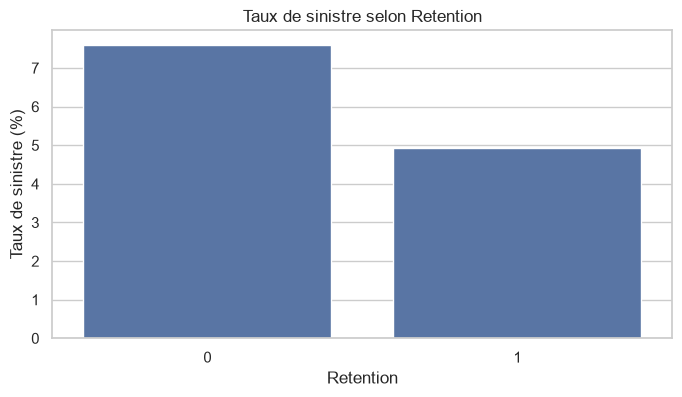

In [51]:
retention_risk = (
    df.groupby("Retention")["Has_Claim"]
    .mean()
    .mul(100)
    .reset_index(name="Taux_sinistre")
)

sns.barplot(
    data=retention_risk,
    x="Retention",
    y="Taux_sinistre"
)

plt.title("Taux de sinistre selon Retention")
plt.ylabel("Taux de sinistre (%)")
plt.show()

In [52]:
age_bins = [
    18,
    35,
    45,
    55,
    65,
    75,
    100
]

age_labels = [
    "18-34",
    "35-44",
    "45-54",
    "55-64",
    "65-74",
    "75+"
]

In [53]:
df["Age_group"] = pd.cut(
    df["Age_client"],
    bins=age_bins,
    labels=age_labels,
    right=False
)

In [54]:
df[
    ["Age_client", "Age_group"]
].head(10)

,Age_client,Age_group
0,84,75+
1,83,75+
2,85,75+
3,85,75+
4,82,75+
5,79,75+
6,79,75+
7,85,75+
8,78,75+
9,82,75+


In [55]:
df["Age_group"].value_counts().sort_index()

Age_group
18-34     2187
35-44    14378
45-54    28434
55-64    32174
65-74    27737
75+      18025
Name: count, dtype: int64

In [56]:
age_risk = df.groupby(
    "Age_group",
    observed=False
).agg(
    Nombre_observations=("PolID", "size"),
    Taux_sinistre=("Has_Claim", "mean"),
    Frequence_moyenne=("Total_NClaims", "mean"),
    Cout_moyen=("Total_Claims", "mean")
)

age_risk["Taux_sinistre"] *= 100

age_risk.round(2)

,Nombre_observations,Taux_sinistre,Frequence_moyenne,Cout_moyen
Age_group,,,,
18-34,2187,7.27,0.09,64.83
35-44,14378,6.13,0.07,35.78
45-54,28434,6.48,0.08,46.89
55-64,32174,6.24,0.07,37.27
65-74,27737,4.60,0.05,24.49
75+,18025,3.78,0.04,19.67


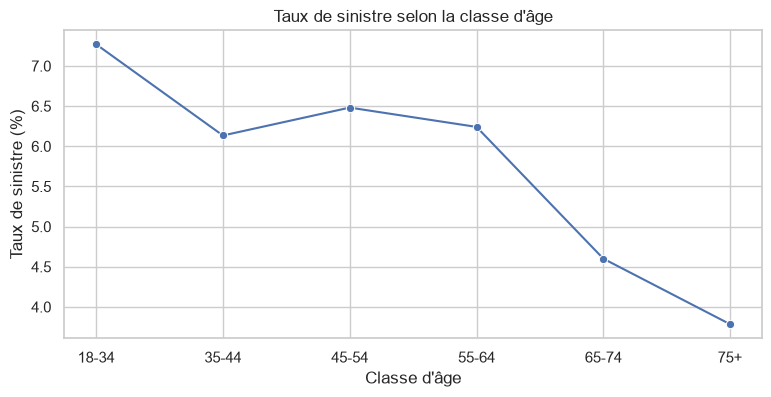

In [57]:
age_risk_plot = age_risk.reset_index()

plt.figure(figsize=(9, 4))

sns.lineplot(
    data=age_risk_plot,
    x="Age_group",
    y="Taux_sinistre",
    marker="o"
)

plt.title("Taux de sinistre selon la classe d'âge")
plt.xlabel("Classe d'âge")
plt.ylabel("Taux de sinistre (%)")
plt.show()

In [58]:
def create_quantile_groups(data, column, number_of_groups=5):
    return pd.qcut(
        data[column],
        q=number_of_groups,
        duplicates="drop"
    )

In [59]:
numerical_risk_summaries = {}

for column in numerical_features:
    group_column = f"{column}_group"

    df[group_column] = create_quantile_groups(
        df,
        column
    )

    summary = df.groupby(
        group_column,
        observed=False
    ).agg(
        Nombre_observations=("PolID", "size"),
        Taux_sinistre=("Has_Claim", "mean"),
        Frequence_moyenne=("Total_NClaims", "mean"),
        Cout_moyen=("Total_Claims", "mean")
    )

    summary["Taux_sinistre"] *= 100

    numerical_risk_summaries[column] = (
        summary.round(2)
    )

In [60]:
numerical_risk_summaries[
    "Car_power_M"
]

,Nombre_observations,Taux_sinistre,Frequence_moyenne,Cout_moyen
Car_power_M_group,,,,
"(3.999, 75.0]",27827,5.30,0.06,31.38
"(75.0, 98.0]",21589,5.78,0.07,34.45
"(98.0, 111.0]",24381,5.64,0.06,33.40
"(111.0, 140.0]",27979,5.77,0.07,31.60
"(140.0, 560.0]",21159,5.38,0.06,42.86


In [61]:
numerical_risk_summaries[
    "Client_Seniority"
]

,Nombre_observations,Taux_sinistre,Frequence_moyenne,Cout_moyen
Client_Seniority_group,,,,
"(5.0009999999999994, 6.308]",24617,5.17,0.06,41.88
"(6.308, 7.562]",24560,5.80,0.07,34.75
"(7.562, 9.273]",24628,6.46,0.07,40.16
"(9.273, 14.905]",24554,5.77,0.07,31.69
"(14.905, 44.706]",24576,4.66,0.05,23.23


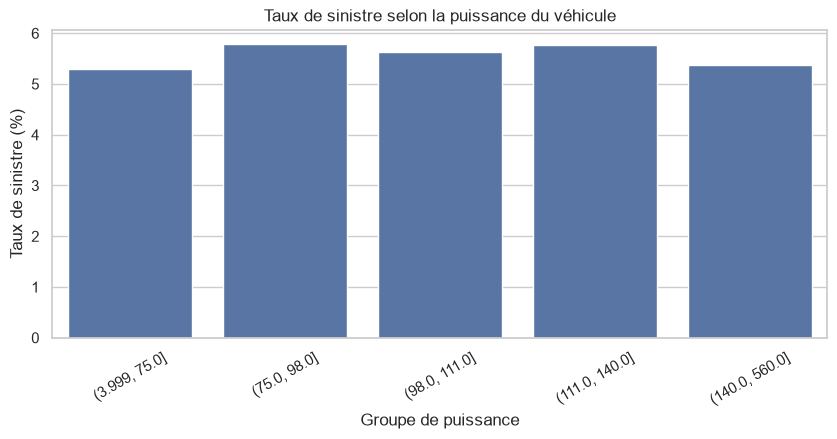

In [62]:
power_group_column = "Car_power_M_group"

power_risk = (
    df.groupby(
        power_group_column,
        observed=False
    )["Has_Claim"]
    .mean()
    .mul(100)
    .reset_index(name="Taux_sinistre")
)

plt.figure(figsize=(10, 4))

sns.barplot(
    data=power_risk,
    x=power_group_column,
    y="Taux_sinistre"
)

plt.title("Taux de sinistre selon la puissance du véhicule")
plt.xlabel("Groupe de puissance")
plt.ylabel("Taux de sinistre (%)")
plt.xticks(rotation=30)
plt.show()

### Conclusion de l’analyse bivariée

Les taux et les coûts de sinistres varient selon certaines caractéristiques des assurés, des véhicules et des contrats.

Ces écarts sont descriptifs et ne permettent pas d’établir une relation causale. Ils peuvent également être influencés par la composition des groupes, la taille des modalités et les interactions entre plusieurs variables.

Les variables présentant des profils de risque différents seront étudiées dans les modèles prédictifs. Pour le clustering, les variables de profil seront utilisées sans intégrer directement les résultats de sinistres.

## 4. Corrélations et redondances entre variables

L’analyse des corrélations permet :

- d’identifier les variables qui évoluent ensemble ;
- de détecter les informations potentiellement redondantes ;
- d’étudier les associations avec les variables de risque ;
- de préparer la sélection des variables et le clustering.

Une corrélation ne prouve pas une relation de causalité.

In [63]:
correlation_features = [
    "gender",
    "Age_client",
    "age_of_car_M",
    "Car_power_M",
    "Car_2ndDriver_M",
    "num_policiesC",
    "metro_code",
    "Policy_PaymentMethodA",
    "Policy_PaymentMethodH",
    "Insuredcapital_content_re",
    "Insuredcapital_continent_re",
    "appartment",
    "Client_Seniority"
]

In [64]:
feature_correlation = df[
    correlation_features
].corr(method="spearman")

feature_correlation.round(2)

,gender,Age_client,age_of_car_M,Car_power_M,Car_2ndDriver_M,num_policiesC,metro_code,Policy_PaymentMethodA,Policy_PaymentMethodH,Insuredcapital_content_re,Insuredcapital_continent_re,appartment,Client_Seniority
gender,1.00,0.14,-0.02,0.14,0.01,-0.02,-0.00,0.04,0.04,0.04,-0.01,-0.02,0.05
Age_client,0.14,1.00,-0.03,-0.11,-0.06,0.17,0.02,0.18,0.08,0.08,0.00,-0.05,0.21
age_of_car_M,-0.02,-0.03,1.00,-0.01,0.01,-0.03,-0.01,0.04,-0.01,-0.00,0.00,0.00,-0.29
Car_power_M,0.14,-0.11,-0.01,1.00,-0.07,-0.10,0.08,-0.02,-0.01,0.15,0.11,0.00,-0.13
Car_2ndDriver_M,0.01,-0.06,0.01,-0.07,1.00,-0.03,0.02,-0.05,-0.01,0.03,0.00,0.01,-0.01
num_policiesC,-0.02,0.17,-0.03,-0.10,-0.03,1.00,0.02,0.00,0.01,-0.04,-0.06,0.00,0.03
metro_code,-0.00,0.02,-0.01,0.08,0.02,0.02,1.00,-0.08,-0.03,0.09,-0.01,0.06,0.00
Policy_PaymentMethodA,0.04,0.18,0.04,-0.02,-0.05,0.00,-0.08,1.00,0.27,0.04,0.05,-0.05,0.02
Policy_PaymentMethodH,0.04,0.08,-0.01,-0.01,-0.01,0.01,-0.03,0.27,1.00,-0.10,-0.16,0.08,0.05
Insuredcapital_content_re,0.04,0.08,-0.00,0.15,0.03,-0.04,0.09,0.04,-0.10,1.00,0.32,-0.09,0.03


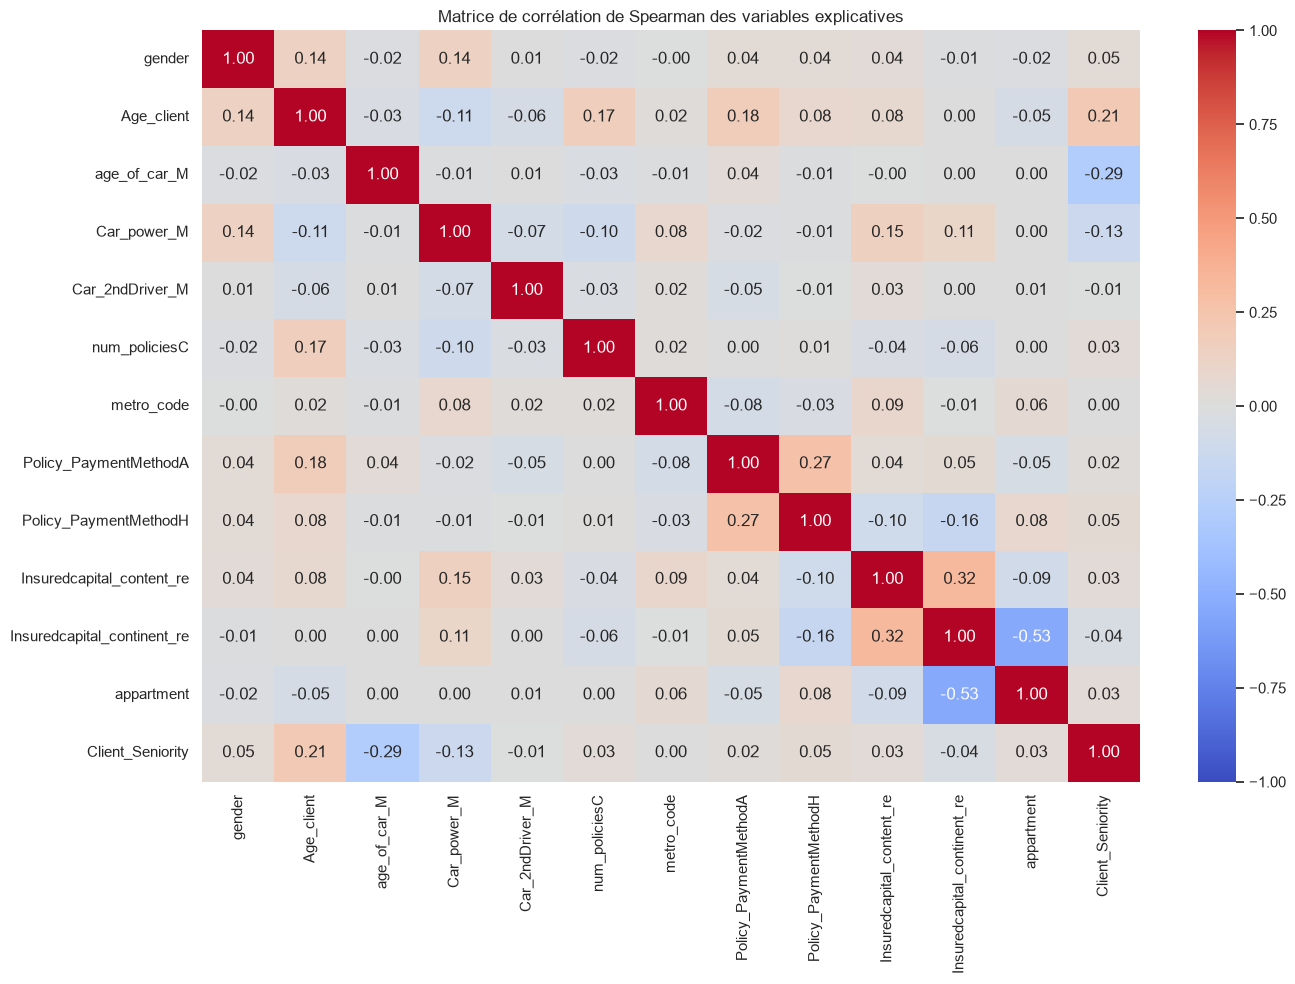

In [65]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    feature_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title(
    "Matrice de corrélation de Spearman "
    "des variables explicatives"
)

plt.tight_layout()
plt.show()

In [66]:
correlation_pairs = (
    feature_correlation
    .where(
        np.triu(
            np.ones(feature_correlation.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

In [67]:
correlation_pairs.columns = [
    "Variable_1",
    "Variable_2",
    "Correlation"
]

In [68]:
correlation_pairs["Correlation_absolue"] = (
    correlation_pairs["Correlation"].abs()
)

In [69]:
correlation_pairs = correlation_pairs.sort_values(
    by="Correlation_absolue",
    ascending=False
)

correlation_pairs.head(15)

,Variable_1,Variable_2,Correlation,Correlation_absolue
141,Insuredcapital_continent_re,appartment,-0.532443,0.532443
127,Insuredcapital_content_re,Insuredcapital_continent_re,0.321155,0.321155
38,age_of_car_M,Client_Seniority,-0.286289,0.286289
99,Policy_PaymentMethodA,Policy_PaymentMethodH,0.271205,0.271205
25,Age_client,Client_Seniority,0.212211,0.212211
20,Age_client,Policy_PaymentMethodA,0.176512,0.176512
18,Age_client,num_policiesC,0.165626,0.165626
114,Policy_PaymentMethodH,Insuredcapital_continent_re,-0.159772,0.159772
48,Car_power_M,Insuredcapital_content_re,0.151636,0.151636
1,gender,Age_client,0.140117,0.140117


In [70]:
strong_correlations = correlation_pairs[
    correlation_pairs["Correlation_absolue"] >= 0.50
]

strong_correlations

,Variable_1,Variable_2,Correlation,Correlation_absolue
141,Insuredcapital_continent_re,appartment,-0.532443,0.532443


In [71]:
risk_correlation_columns = (
    correlation_features
    + [
        "Has_Claim",
        "Total_NClaims",
        "Total_Claims"
    ]
)

risk_correlations = df[
    risk_correlation_columns
].corr(method="spearman")

In [72]:
target_correlations = risk_correlations[
    [
        "Has_Claim",
        "Total_NClaims",
        "Total_Claims"
    ]
].drop(
    index=[
        "Has_Claim",
        "Total_NClaims",
        "Total_Claims"
    ]
)

target_correlations.round(3)

,Has_Claim,Total_NClaims,Total_Claims
gender,-0.002,-0.002,0.003
Age_client,-0.041,-0.041,-0.034
age_of_car_M,-0.002,-0.002,-0.004
Car_power_M,0.002,0.002,0.005
Car_2ndDriver_M,0.026,0.026,0.022
num_policiesC,-0.010,-0.010,-0.008
metro_code,-0.002,-0.002,-0.003
Policy_PaymentMethodA,-0.031,-0.031,-0.027
Policy_PaymentMethodH,-0.014,-0.014,-0.010
Insuredcapital_content_re,0.002,0.002,0.001


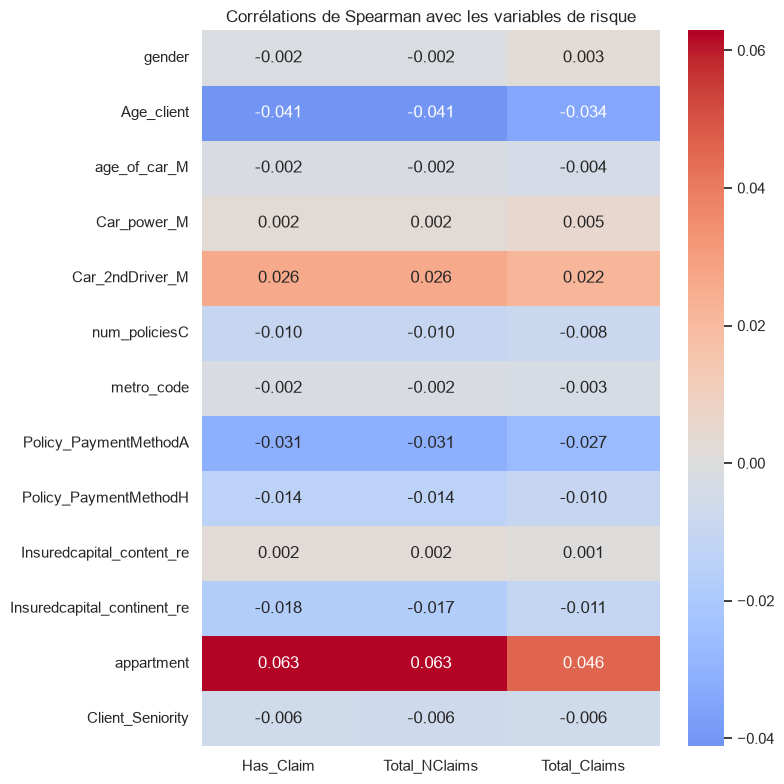

In [73]:
plt.figure(figsize=(8, 8))

sns.heatmap(
    target_correlations,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Corrélations de Spearman avec les variables de risque"
)

plt.tight_layout()
plt.show()

In [74]:
capital_correlation = df[
    [
        "Insuredcapital_content_re",
        "Insuredcapital_continent_re"
    ]
].corr(method="spearman")

capital_correlation

,Insuredcapital_content_re,Insuredcapital_continent_re
Insuredcapital_content_re,1.000000,0.321155
Insuredcapital_continent_re,0.321155,1.000000


In [75]:
plot_sample = df.sample(
    n=10000,
    random_state=42
)

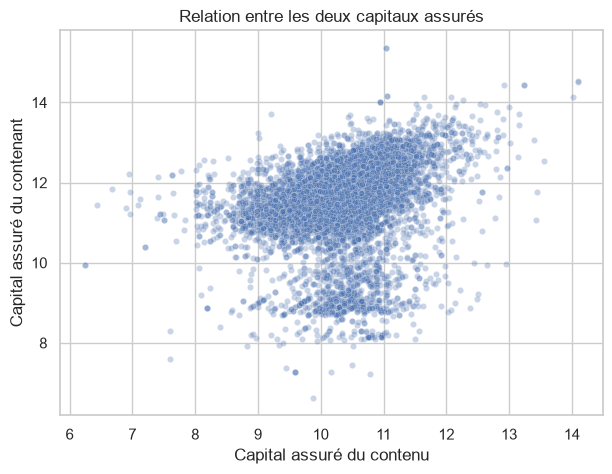

In [76]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=plot_sample,
    x="Insuredcapital_content_re",
    y="Insuredcapital_continent_re",
    alpha=0.3,
    s=20
)

plt.title("Relation entre les deux capitaux assurés")
plt.xlabel("Capital assuré du contenu")
plt.ylabel("Capital assuré du contenant")
plt.show()

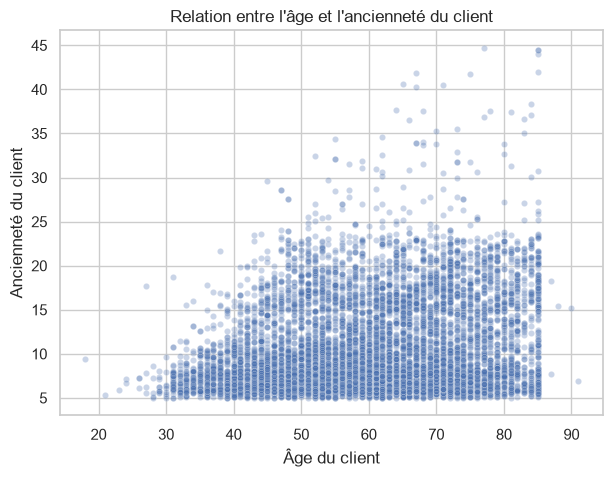

In [77]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=plot_sample,
    x="Age_client",
    y="Client_Seniority",
    alpha=0.3,
    s=20
)

plt.title("Relation entre l'âge et l'ancienneté du client")
plt.xlabel("Âge du client")
plt.ylabel("Ancienneté du client")
plt.show()

In [ ]:
feature_variability = []

for column in correlation_features:
    most_common_rate = (
        df[column]
        .value_counts(normalize=True)
        .iloc[0]
        * 100
    )

    feature_variability.append({
        "Variable": column,
        "Nombre_modalites": df[column].nunique(),
        "Modalite_majoritaire_pct": most_common_rate
    })

feature_variability_df = pd.DataFrame(
    feature_variability
).sort_values(
    by="Modalite_majoritaire_pct",
    ascending=False
)

feature_variability_df.round(2)

### Conclusion sur les corrélations

La matrice de corrélation permet d’identifier les relations entre les variables explicatives et les éventuelles redondances.

Les associations individuelles avec les cibles de risque peuvent rester faibles en raison de la rareté des sinistres, des relations non linéaires et des interactions entre plusieurs caractéristiques.

Aucune variable ne sera supprimée uniquement à partir d’un coefficient de corrélation. La sélection finale dépendra également de l’interprétation métier, des performances des modèles et de la stabilité temporelle.

Avant le clustering, les variables numériques devront être standardisées afin que les différences d’échelle ne dominent pas le calcul des distances.

## 5. Analyse temporelle et stabilité des données

Cette section étudie l’évolution du portefeuille et du risque entre les cinq années. Elle prépare la validation temporelle, la détection du drift et l’apprentissage continu.

In [78]:
temporal_summary = df.groupby("year").agg(
    Nombre_observations=("PolID", "size"),
    Nombre_contrats=("PolID", "nunique"),
    Taux_sinistre=("Has_Claim", "mean"),
    Taux_sinistre_paye=("Has_Paid_Claim", "mean"),
    Frequence_moyenne=("Total_NClaims", "mean"),
    Cout_moyen=("Total_Claims", "mean"),
    Cout_total=("Total_Claims", "sum")
)

In [79]:
temporal_summary[
    [
        "Taux_sinistre",
        "Taux_sinistre_paye"
    ]
] *= 100

temporal_summary.round(2)

,Nombre_observations,Nombre_contrats,Taux_sinistre,Taux_sinistre_paye,Frequence_moyenne,Cout_moyen,Cout_total
year,,,,,,,
1,40284,40284,5.84,3.52,0.07,36.74,1479835.70
2,29818,29818,5.78,3.56,0.07,39.93,1190689.53
3,22505,22505,5.73,3.36,0.07,36.88,829927.79
4,17044,17044,5.07,3.02,0.06,26.31,448409.87
5,13284,13284,4.67,2.72,0.05,20.60,273669.78


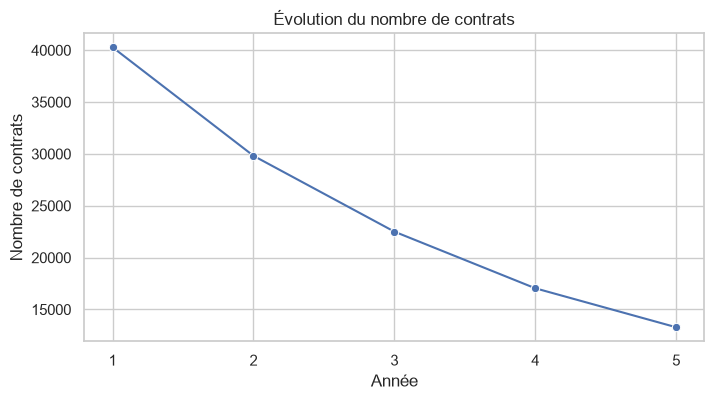

In [80]:
portfolio_size = (
    temporal_summary
    .reset_index()
)

plt.figure(figsize=(8, 4))

sns.lineplot(
    data=portfolio_size,
    x="year",
    y="Nombre_contrats",
    marker="o"
)

plt.title("Évolution du nombre de contrats")
plt.xlabel("Année")
plt.ylabel("Nombre de contrats")
plt.xticks(sorted(df["year"].unique()))
plt.show()

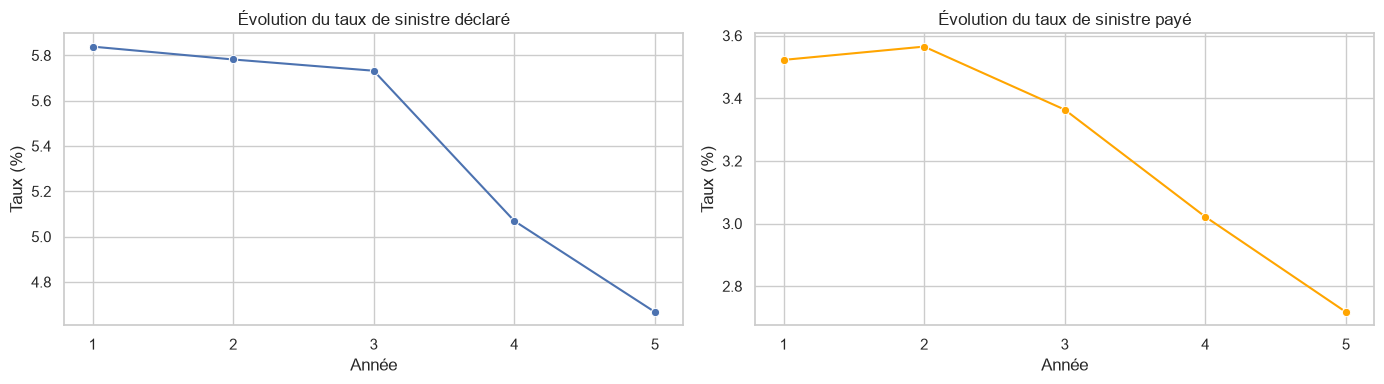

In [81]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 4)
)

sns.lineplot(
    data=portfolio_size,
    x="year",
    y="Taux_sinistre",
    marker="o",
    ax=axes[0]
)

axes[0].set_title(
    "Évolution du taux de sinistre déclaré"
)
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Taux (%)")

sns.lineplot(
    data=portfolio_size,
    x="year",
    y="Taux_sinistre_paye",
    marker="o",
    color="orange",
    ax=axes[1]
)

axes[1].set_title(
    "Évolution du taux de sinistre payé"
)
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Taux (%)")

for axis in axes:
    axis.set_xticks(
        sorted(df["year"].unique())
    )

plt.tight_layout()
plt.show()

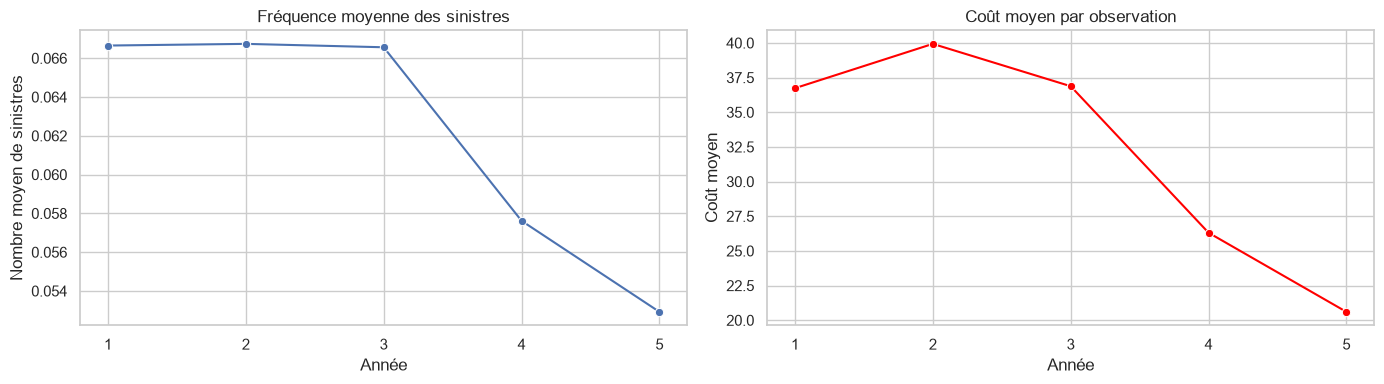

In [82]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 4)
)

sns.lineplot(
    data=portfolio_size,
    x="year",
    y="Frequence_moyenne",
    marker="o",
    ax=axes[0]
)

axes[0].set_title(
    "Fréquence moyenne des sinistres"
)
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nombre moyen de sinistres")

sns.lineplot(
    data=portfolio_size,
    x="year",
    y="Cout_moyen",
    marker="o",
    color="red",
    ax=axes[1]
)

axes[1].set_title(
    "Coût moyen par observation"
)
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Coût moyen")

for axis in axes:
    axis.set_xticks(
        sorted(df["year"].unique())
    )

plt.tight_layout()
plt.show()

In [83]:
positive_claims_df = df[
    df["Total_Claims"] > 0
].copy()

In [84]:
positive_cost_summary = (
    positive_claims_df
    .groupby("year")["Total_Claims"]
    .agg(
        Nombre_sinistres_payes="count",
        Cout_moyen="mean",
        Cout_median="median",
        Cout_maximum="max"
    )
)

positive_cost_summary.round(2)

,Nombre_sinistres_payes,Cout_moyen,Cout_median,Cout_maximum
year,,,,
1,1419,1042.87,669.11,20459.72
2,1063,1120.12,552.75,91382.97
3,757,1096.34,400.00,109720.71
4,515,870.70,388.90,13837.72
5,361,758.09,341.34,9009.20


In [85]:
cost_quantiles_by_year = (
    positive_claims_df
    .groupby("year")["Total_Claims"]
    .quantile([0.50, 0.90, 0.95, 0.99])
    .unstack()
)

In [86]:
cost_quantiles_by_year.columns = [
    "Q50",
    "Q90",
    "Q95",
    "Q99"
]

cost_quantiles_by_year.round(2)

,Q50,Q90,Q95,Q99
year,,,,
1,669.11,1912.92,4179.71,10301.69
2,552.75,1764.00,3737.93,14468.25
3,400.00,1764.00,3634.42,8048.44
4,388.90,1764.00,2965.29,10852.23
5,341.34,1644.11,2560.21,7485.33


In [87]:
quantile_plot_data = (
    cost_quantiles_by_year
    .reset_index()
    .melt(
        id_vars="year",
        var_name="Quantile",
        value_name="Montant"
    )
)

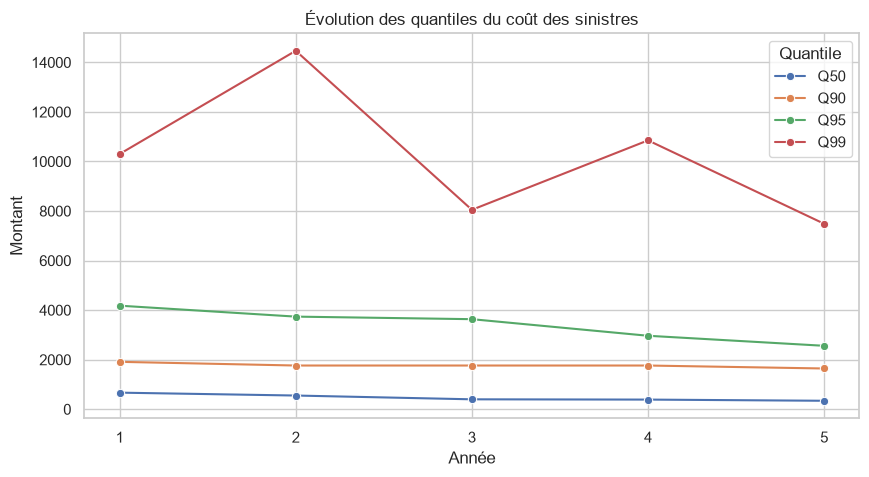

In [88]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=quantile_plot_data,
    x="year",
    y="Montant",
    hue="Quantile",
    marker="o"
)

plt.title("Évolution des quantiles du coût des sinistres")
plt.xlabel("Année")
plt.ylabel("Montant")
plt.xticks(sorted(df["year"].unique()))
plt.show()

In [89]:
numerical_means_by_year = (
    df.groupby("year")[numerical_features]
    .mean()
)

numerical_means_by_year.round(2)

,Age_client,age_of_car_M,Car_power_M,Insuredcapital_content_re,Insuredcapital_continent_re,Client_Seniority
year,,,,,,
1,58.17,8.24,111.63,10.32,11.47,10.07
2,59.37,8.74,111.68,10.33,11.48,10.22
3,60.35,9.11,111.39,10.33,11.48,10.37
4,61.15,9.49,111.40,10.34,11.49,10.47
5,61.79,9.70,111.34,10.34,11.50,10.52


In [90]:
standardized_means = (
    numerical_means_by_year
    - numerical_means_by_year.mean()
) / numerical_means_by_year.std()

In [91]:
standardized_means_plot = (
    standardized_means
    .reset_index()
    .melt(
        id_vars="year",
        var_name="Variable",
        value_name="Moyenne_standardisee"
    )
)

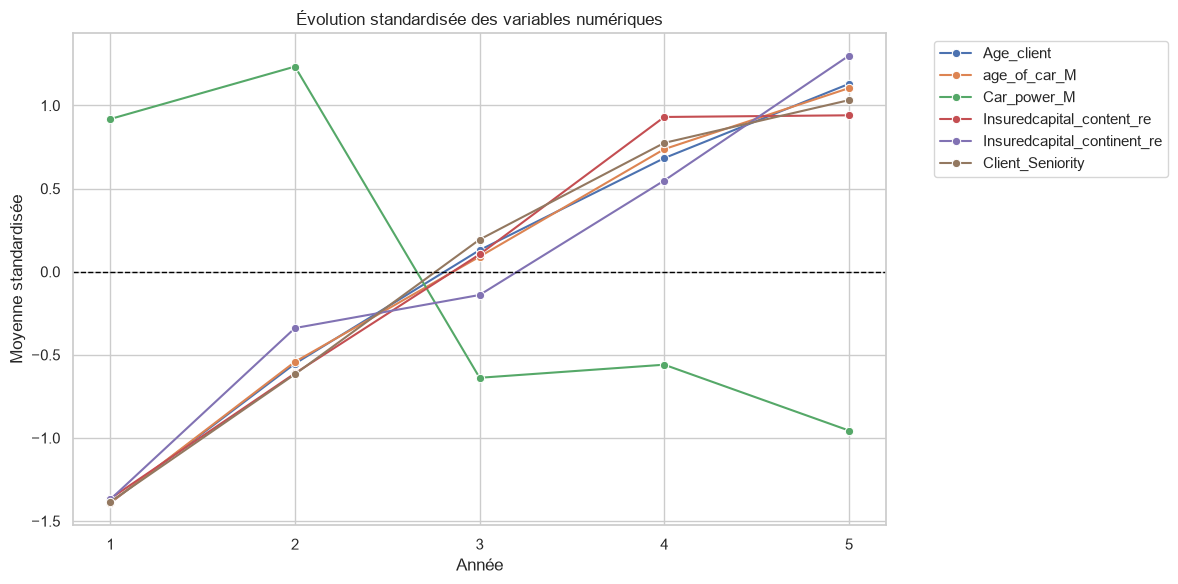

In [92]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=standardized_means_plot,
    x="year",
    y="Moyenne_standardisee",
    hue="Variable",
    marker="o"
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.title(
    "Évolution standardisée des variables numériques"
)
plt.xlabel("Année")
plt.ylabel("Moyenne standardisée")
plt.xticks(sorted(df["year"].unique()))
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [93]:
binary_rates_by_year = (
    df.groupby("year")[binary_features]
    .mean()
    .mul(100)
)

binary_rates_by_year.round(2)

,gender,Car_2ndDriver_M,num_policiesC,metro_code,Policy_PaymentMethodA,Policy_PaymentMethodH,appartment
year,,,,,,,
1,77.75,14.93,82.26,17.11,74.88,92.16,63.35
2,77.83,14.22,81.63,16.62,76.48,92.36,63.03
3,77.87,13.37,80.74,15.97,77.94,92.70,62.90
4,77.87,12.70,79.56,15.51,79.34,93.08,62.46
5,77.90,12.03,78.54,15.26,80.63,93.39,62.20


In [94]:
binary_rates_plot = (
    binary_rates_by_year
    .reset_index()
    .melt(
        id_vars="year",
        var_name="Variable",
        value_name="Pourcentage_modalite_1"
    )
)

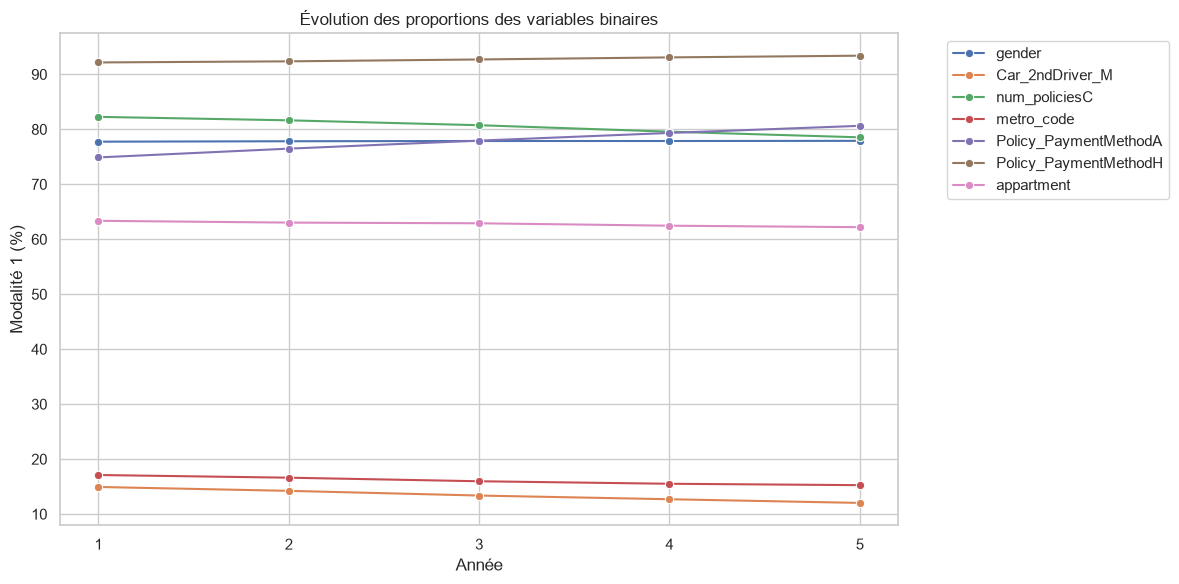

In [95]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=binary_rates_plot,
    x="year",
    y="Pourcentage_modalite_1",
    hue="Variable",
    marker="o"
)

plt.title(
    "Évolution des proportions des variables binaires"
)
plt.xlabel("Année")
plt.ylabel("Modalité 1 (%)")
plt.xticks(sorted(df["year"].unique()))
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 6. Conclusion générale de l’EDA

L’analyse exploratoire met en évidence plusieurs caractéristiques importantes :

- le portefeuille possède une structure longitudinale avec un suivi maximal de cinq années ;
- le nombre de contrats observés diminue au fil du temps ;
- les sinistres sont rares, ce qui crée un fort déséquilibre des cibles ;
- les montants des sinistres sont très asymétriques et présentent une queue lourde ;
- certaines caractéristiques des assurés et des véhicules sont associées à des différences de fréquence ou de coût ;
- les variables explicatives possèdent des échelles différentes et devront être standardisées avant le clustering ;
- la composition du portefeuille et les indicateurs de risque peuvent évoluer dans le temps ;
- la variable `Types` ne devra pas être utilisée comme variable explicative en raison du risque de fuite de données ;
- l’utilisation de `Retention` dépendra de sa disponibilité réelle au moment de la prédiction.

Ces observations justifient :

1. une validation temporelle des modèles ;
2. une modélisation séparée de la fréquence et de la sévérité ;
3. l’utilisation de métriques adaptées au déséquilibre ;
4. une surveillance du data drift et du concept drift ;
5. une procédure de réentraînement dans le pipeline MLOps.